# Этап №3. | AI/ML | Парсинг данных

**Цель этапа:** подготовка нормативной документации (ПУЭ) для векторного поиска — от исходников до загрузки в векторную базу.



**Пайплайн:** `raw` → `extracted` → `chunked` → `embeddings` (векторная база)

**Содержание:**
1. Конвертация docx → Markdown (raw → extracted)
2. Редактирование md (глава 1)
3. Чанкирование md → jsonl (extracted → chunked)
4. Векторная база данныз
5. Загрузка в базу данных и тестовые запросы

## 1. Конвертация *.docx → Markdown

Перевёл все файлы *.docx «ПРАВИЛА УСТРОЙСТВА ЭЛЕКТРОУСТАНОВОК» в файлы формата Markdown.

**Результат:** картинки выгружены в отдельные папки — так проще связывать их с текстом в чанках.

### 1.1. Исходные данные (raw)

| Путь | Содержимое |
|------|------------|
| `data/raw/Нормативная база/ПУЭ/` | Исходные docx-файлы ПУЭ |
| `data/raw/База исходники/` | RTF, docx и др. нормативные документы |



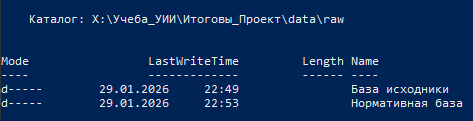  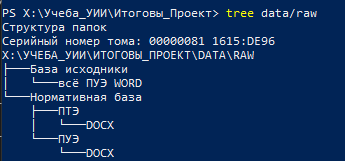

### 1.2. Результат (extracted)

- [data/extracted](https://github.com/kirag-ozyaz/Diplom_AI/tree/main/data/extracted) — файлы *.md по главам (1.1.md, 1.2.md, … 7.10.md)
- Рядом с каждым .md — папка с изображениями главы

*Для наглядности: фрагмент 1.1.md (первые 20–30 строк) — заголовки, пункты 1.1.1, 1.1.2*

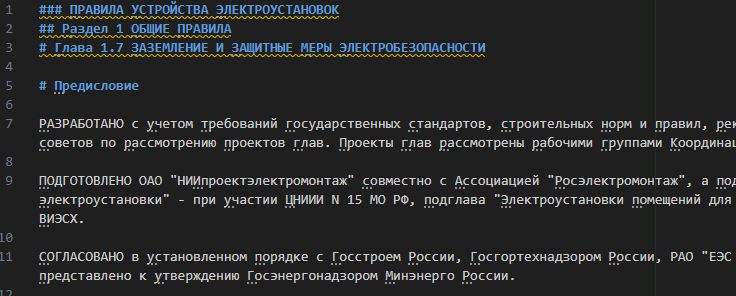

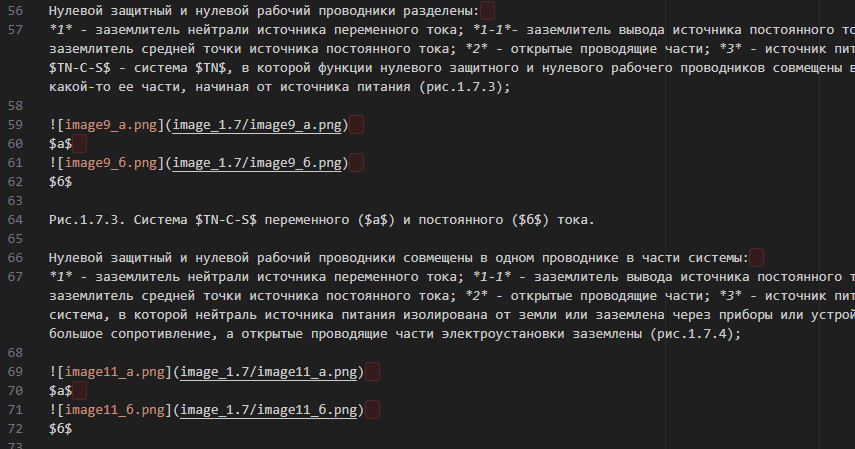

### 1.3. Скрипты

| Скрипт | Назначение |
|--------|------------|
| [docx_to_md_images_1.py](https://github.com/kirag-ozyaz/Diplom_AI/blob/main/src/preprocessing/Create_mds/docx_to_md_images_1.py) | Обработка одного файла |
| [generator.py](https://github.com/kirag-ozyaz/Diplom_AI/blob/main/src/preprocessing/Create_mds/generator.py) | Массовая обработка |



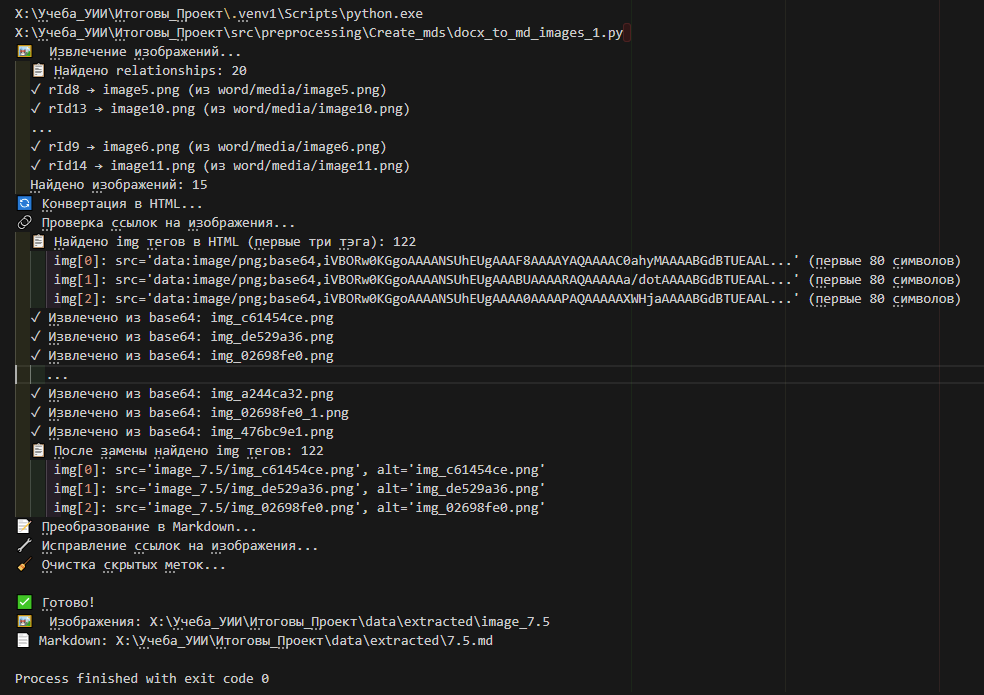

## 2. Редактирование md (глава 1)

Отредактировал файлы *.md (глава 1) для отработки пайплайна.

**Сделано:**
- Убраны повторяющиеся картинки
- Выделены формулы и таблицы (для корректного отображения в RAG)

*Для наглядности: блок «До» / «После» — один и тот же фрагмент md до и после правок*

## 3. Чанкирование md → jsonl

Перевёл файлы *.md в чанки *.jsonl (JSON Lines).

**Стратегия чанкинга:** пункты по шаблону (X.Y.Z) — один пункт = один чанк. Изображения остаются внутри чанков. Подходит для векторного поиска по релевантным фрагментам.

### 3.1. Результат (chunked)

- [data/chunked](https://github.com/kirag-ozyaz/Diplom_AI/tree/main/data/chunked) — файлы `*.chunked.jsonl` (1.1.chunked.jsonl, 4.4.chunked.jsonl, …)

*Для наглядности: список файлов chunked*

### 3.2. Пример чанка (структура)

Каждая строка jsonl — объект с полями:
- `id` — уникальный идентификатор (например, `pue_1.1.1_543e2d24`)
- `metadata` — Document, Section, Chapter, Paragraph, Clause, source_file, contains_tables, contains_images
- `content` — текст пункта с контекстом (Раздел → Глава → Пункт)

*Для наглядности: 1–2 примера чанка в отформатированном виде (json.dumps с indent)*

### 3.3. Скрипты

| Скрипт | Назначение |
|--------|------------|
| [md_to_chunked_2](https://github.com/kirag-ozyaz/Diplom_AI/blob/main/src/preprocessing/Create_chunkeds/md_to_chunked_2) | Обработка одного файла |
| [generator.py](https://github.com/kirag-ozyaz/Diplom_AI/blob/main/src/preprocessing/Create_chunkeds/generator.py) | Массовая обработка |

*Для наглядности: лог — количество чанков, обработанных файлов*

## 4. Векторная БД Milvus

В качестве хранения эмбеддингов выбираем векторную базу данных Milvus.


**Инфраструктура:**
- [infra](https://github.com/kirag-ozyaz/Diplom_AI/tree/main/infra) — docker-compose для Milvus
- Attu — веб-интерфейс для просмотра коллекций и данных

### 4.1. Что показать в Milvus (Attu)

| Материал | Описание |
|----------|----------|
| Скриншот списка коллекций | Имя коллекции `diplom_multimodal`, количество сущностей |
| Скриншот схемы коллекции | Поля: id, embedding (vector), chapter, text, has_image, image_paths, … |
| Скриншот данных | Несколько записей с текстом и метаданными |

*Для наглядности: 1–2 скриншота Attu — коллекции и пример записей*

## 5. Загрузка чанков в БД и тестовые запросы

Загружены чанки в Milvus. Отдельно — текст и картинки (картинки через CLIP — в планах). Эмбеддинги текста считаются при загрузке.

### 5.1. Скрипты

| Скрипт | Назначение |
|--------|------------|
| [load_data.py](https://github.com/kirag-ozyaz/Diplom_AI/blob/main/src/preprocessing/Create_embeddings/load_data.py) | Загрузка данных в коллекцию |
| [multimodal_rag.py](https://github.com/kirag-ozyaz/Diplom_AI/blob/main/src/preprocessing/Create_embeddings/multimodal_rag.py) | Класс MultimodalRAG — загрузка, поиск |
| [query_test.py](https://github.com/kirag-ozyaz/Diplom_AI/blob/main/src/preprocessing/Create_embeddings/query_test.py) | Тестовые запросы к готовой коллекции |

*Для наглядности: лог загрузки — количество загруженных чанков, время*

### 5.2. Что показать по запросам

| Материал | Описание |
|----------|----------|
| Пример запроса | Текст запроса (напр. «система заземления» или «нулевой защитный проводник») |
| Топ-N результатов | Для каждого: score, chapter, фрагмент текста, наличие изображений |
| Таблица | Запрос → Найденный пункт (1.1.X) → Score |

*Для наглядности: вывод `query_test.py` — 2–3 примера запросов с результатами*

---

## Итог этапа

| Статус | Описание |
|--------|----------|
| ✅ | Данные в векторной БД Milvus |
| ✅ | Тестовые запросы проверяются |
| 🔜 | Доработка RAG, поиск по картинкам (CLIP) |

